In [60]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# # Convert string representation to actual list, checking for NaN values first
df['job_skills' ] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [61]:
df_UK = df[(df['job_country'] == 'United Kingdom')].dropna(subset=['salary_year_avg'])

In [62]:
job_titles  = df_UK['job_title_short'].value_counts().index[:6].to_list()

job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [63]:
df_UK_Top6 = df_UK[df_UK['job_title_short'].isin(job_titles)]

In [64]:
job_order =df_UK_Top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

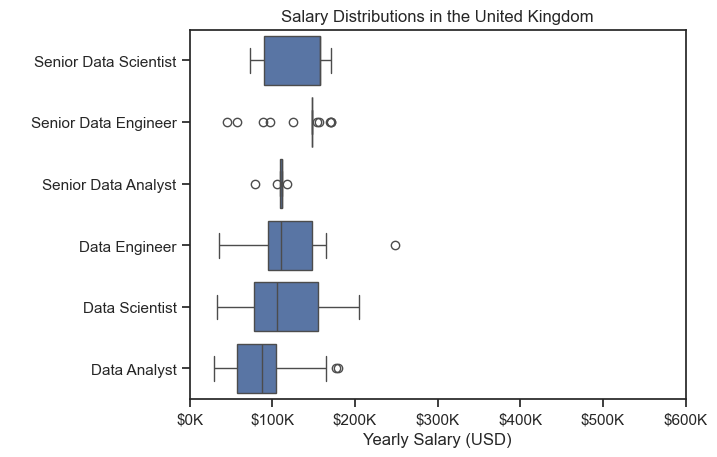

In [65]:
sns.boxplot(data=df_UK_Top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme (style='ticks', palette='pastel')

plt.title('Salary Distributions in the United Kingdom')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel(' ')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.xlim(0, 600000)
plt.show()

In [66]:
df_DA_UK = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United Kingdom')].copy()


df_DA_UK = df_DA_UK.dropna(subset=['salary_year_avg'])

df_DA_UK = df_DA_UK.explode('job_skills')

df_DA_UK[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
2602,51014.0,excel
2602,51014.0,word
2602,51014.0,outlook
16526,100500.0,sql
16526,100500.0,jupyter


In [67]:
df_DA_top_pay = df_DA_UK.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
pandas,1,177283.0
tensorflow,1,177283.0
numpy,1,177283.0
c++,1,177283.0
pytorch,1,177283.0
aurora,1,165000.0
mongodb,2,165000.0
mysql,3,165000.0
aws,3,165000.0


In [68]:
df_DA_skills = df_DA_UK.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
tableau,13,100500.0
sql,33,98500.0
looker,6,96012.5
python,25,89100.0
power bi,7,89100.0
sas,8,80007.0
r,9,77017.5
excel,29,75550.0
go,9,71000.0


/var/folders/g_/b4ygh17n5tn8m8dd075nkhj40000gn/T/ipykernel_34679/2169646319.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_DA_Top_pay, x='median', y=df_DA_Top_pay.index, ax=ax[0], palette='dark:b_r')
/var/folders/g_/b4ygh17n5tn8m8dd075nkhj40000gn/T/ipykernel_34679/2169646319.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend().remove()


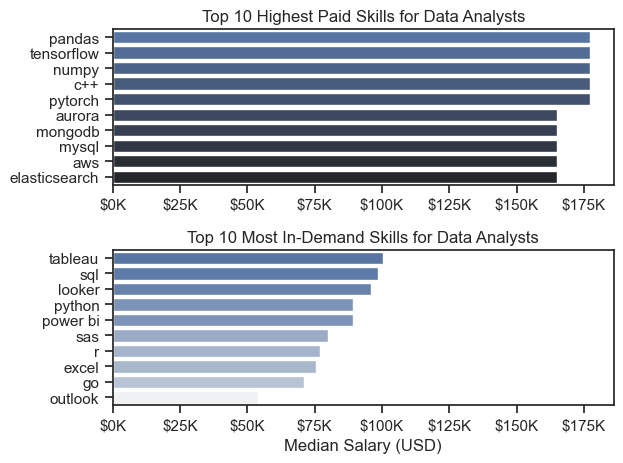

In [79]:
ig, ax = plt.subplots(2, 1)  

sns.set_theme(style='ticks' )

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_Top_pay, x='median', y=df_DA_Top_pay.index, ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
# original code:
# df_DA_Top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) 
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analystsr')
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[1], palette='light:b')
ax[1].legend().remove()
# original code:
# df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


plt.tight_layout()
plt.show()

In [76]:
df_DA_UK.groupby('job_skills')['salary_year_avg'].agg(['count', 'median', 'mean', 'min', 'max']) \
    .sort_values('median', ascending=False) \
    .head(20)

,count,median,mean,min,max
job_skills,,,,,
pandas,1,177283.0,177283.000000,177283.0,177283.0
tensorflow,1,177283.0,177283.000000,177283.0,177283.0
numpy,1,177283.0,177283.000000,177283.0,177283.0
c++,1,177283.0,177283.000000,177283.0,177283.0
pytorch,1,177283.0,177283.000000,177283.0,177283.0
aurora,1,165000.0,165000.000000,165000.0,165000.0
mongodb,2,165000.0,165000.000000,165000.0,165000.0
mysql,3,165000.0,142833.333333,98500.0,165000.0
aws,3,165000.0,147058.333333,111175.0,165000.0
